Dataset Shape: (150, 4)
Target Classes: ['setosa' 'versicolor' 'virginica']
Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


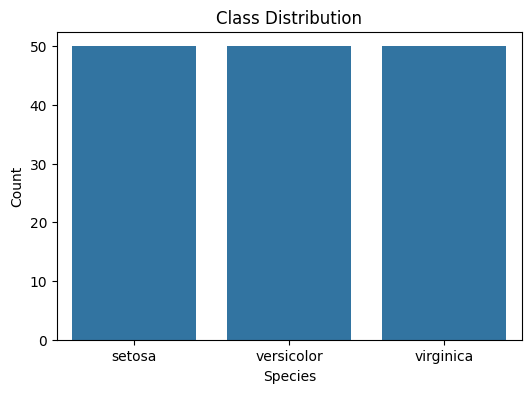

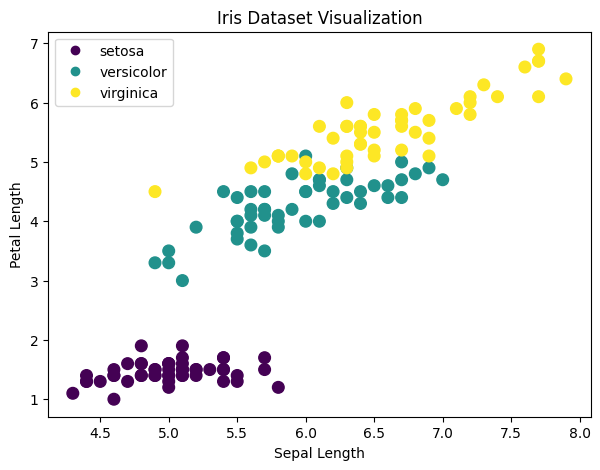


Accuracy: 0.9666666666666667

Confusion Matrix:

[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]


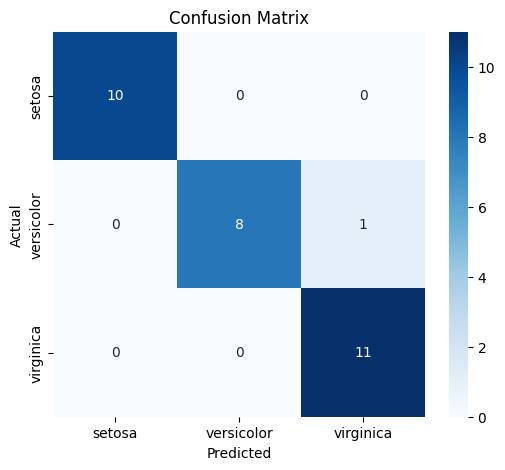


Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



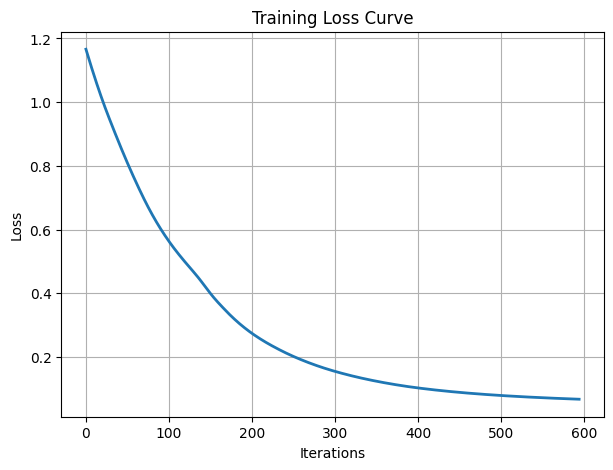

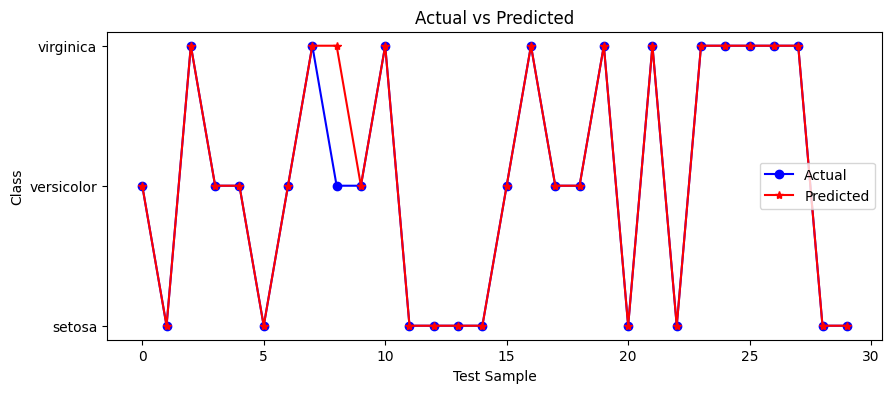


Sample Predictions:

Sample 1: Actual = versicolor, Predicted = versicolor
Sample 2: Actual = setosa, Predicted = setosa
Sample 3: Actual = virginica, Predicted = virginica
Sample 4: Actual = versicolor, Predicted = versicolor
Sample 5: Actual = versicolor, Predicted = versicolor
Sample 6: Actual = setosa, Predicted = setosa
Sample 7: Actual = versicolor, Predicted = versicolor
Sample 8: Actual = virginica, Predicted = virginica
Sample 9: Actual = versicolor, Predicted = virginica
Sample 10: Actual = versicolor, Predicted = versicolor


In [3]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -----------------------------
# Load Iris Dataset
# -----------------------------
iris = load_iris()
X = iris.data
y = iris.target

print("Dataset Shape:", X.shape)
print("Target Classes:", iris.target_names)
print("Feature Names:", iris.feature_names)

# -----------------------------
# Visualize Class Distribution
# -----------------------------
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.xticks([0,1,2], list(iris.target_names))
plt.title("Class Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

# -----------------------------
# Scatter Plot
# -----------------------------
plt.figure(figsize=(7,5))
scatter = plt.scatter(
    X[:,0],
    X[:,2],
    c=y,
    cmap="viridis",
    s=70
)

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("Iris Dataset Visualization")

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=list(iris.target_names)
)

plt.show()

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Build MLP Model
# -----------------------------
mlp = MLPClassifier(
    hidden_layer_sizes=(10,10),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

# -----------------------------
# Train Model
# -----------------------------
mlp.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------
y_pred = mlp.predict(X_test)

# -----------------------------
# Accuracy
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

# Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=list(iris.target_names),
    yticklabels=list(iris.target_names)
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# -----------------------------
# Classification Report
# -----------------------------
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=list(iris.target_names)
))

# -----------------------------
# Training Loss Curve
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(mlp.loss_curve_, linewidth=2)
plt.title("Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# -----------------------------
# Actual vs Predicted
# -----------------------------
plt.figure(figsize=(10,4))

plt.plot(y_test, 'bo-', label="Actual")
plt.plot(y_pred, 'r*-', label="Predicted")

plt.yticks([0,1,2], list(iris.target_names))
plt.xlabel("Test Sample")
plt.ylabel("Class")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

# -----------------------------
# Sample Predictions
# -----------------------------
print("\nSample Predictions:\n")

for i in range(10):
    print(f"Sample {i+1}: Actual = {iris.target_names[y_test[i]]}, "
          f"Predicted = {iris.target_names[y_pred[i]]}")